We estimate linear regression coefficients for the association between housing price in the contiguous United States and several covariates: income, night-time lights, and road length. We compare map-only, GT-only ("classical"), and PPI methods.

We will do an "Error-in-X" regression. For nightlights and road length, we use a map product along with a small calibration set of ground truth points. For housing price and income, we use ground truth for all points.  

Map product points and ground truth points are both from MOSAIKS paper dataset (Rolf et al, 2021): https://github.com/Global-Policy-Lab/mosaiks-paper

In [1]:
import numpy as np
import pandas as pd
import pickle
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.weightstats import _zconfint_generic
import statsmodels
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns

# PPI for linear regression

The code for PPI for linear regression, as described in Section 2.2 of the paper, is given below. (The same code is used in all three of our linear regression notebooks.)

The main function is **bootstrap_ppi** which gives 100*(1-alpha) percent PPI confidence intervals for the regression coefficients. X and Y are the ground truth covariates and outcomes (respectively), Xhat and Yhat are the remotely sensed covariates and outcomes at the same locations as the ground truth, and Xhat_unlabeled and Yhat_unlabeled are a larger dataset of remotely sensed covariates and outcomes that do not have corresponding ground truth values available. 

Additionally, **classical_ols_ci** computes the 100*(1-alpha) percent GT-only confidence intervals.

In [2]:
def ppi_pointestimate(X, Xhat, Xhat_unlabeled, Y, Yhat, Yhat_unlabeled, tuning_matrix):
    coeff_calibration = OLS(Y, exog=statsmodels.tools.add_constant(X)).fit().params
    coeff_preds_calibration = OLS(Yhat, exog=statsmodels.tools.add_constant(Xhat)).fit().params
    coeff_preds_all = OLS(Yhat_unlabeled, exog=statsmodels.tools.add_constant(Xhat_unlabeled)).fit().params
    
    coeff_ppi = tuning_matrix @ coeff_preds_all + (coeff_calibration - tuning_matrix @ coeff_preds_calibration)
    
    return coeff_ppi
    
def cross_cov(A, B):
    '''
    A is (p x n)
    B is (p x n)
    
    Output: (p x p) cross-covariance matrix
    '''
    n = A.shape[1]
    C = 1/(n-1) * (A-A.mean(axis=1)[:, np.newaxis]) @ (B-B.mean(axis=1)[:, np.newaxis]).T
    return C

def resample_datapoints(X, Xhat, Xhat_unlabeled, Y, Yhat, Yhat_unlabeled):
    # resample datapoints for a single bootstrap trial
    calibration_indices = np.random.choice(np.arange(0, len(X)), size=len(X), replace=True)
    preds_indices = np.random.choice(np.arange(0, len(Xhat_unlabeled)), size=len(Xhat_unlabeled), replace=True)

    X_trial = X[calibration_indices]
    Xhat_trial = Xhat[calibration_indices]
    Xhat_unlabeled_trial = Xhat_unlabeled[preds_indices]
    Y_trial = Y[calibration_indices]
    Yhat_trial = Yhat[calibration_indices]
    Yhat_unlabeled_trial = Yhat_unlabeled[preds_indices]
    
    return X_trial, Xhat_trial, Xhat_unlabeled_trial, Y_trial, Yhat_trial, Yhat_unlabeled_trial

def bootstrap_ppi(X, Xhat, Xhat_unlabeled, Y, Yhat, Yhat_unlabeled, tune=True, trials=100, alpha=0.05):
    
    if tune:
        # bootstrap to get tuning matrix
        coeff_calibration_list = []
        coeff_preds_calibration_list = []
        for trial in tqdm(range(trials)):
            X_trial, Xhat_trial, Xhat_unlabeled_trial, Y_trial, Yhat_trial, Yhat_unlabeled_trial = resample_datapoints(X, Xhat, Xhat_unlabeled, Y, Yhat, Yhat_unlabeled)

            coeff_calibration = OLS(Y_trial, exog=statsmodels.tools.add_constant(X_trial)).fit().params
            coeff_calibration_list.append(coeff_calibration)

            coeff_preds_calibration = OLS(Yhat_trial, exog=statsmodels.tools.add_constant(Xhat_trial)).fit().params
            coeff_preds_calibration_list.append(coeff_preds_calibration)

        coeff_calibration_list = np.array(coeff_calibration_list).T
        coeff_preds_calibration_list = np.array(coeff_preds_calibration_list).T

        tuning_matrix = cross_cov(coeff_calibration_list, coeff_preds_calibration_list) @ np.linalg.inv(np.cov(coeff_preds_calibration_list))
    else:
        tuning_matrix = np.identity(X.shape[1]+1)
    
    # bootstrap to get confidence interval for coefficient
    outputs = []
    for trial in tqdm(range(trials)):
        X_trial, Xhat_trial, Xhat_unlabeled_trial, Y_trial, Yhat_trial, Yhat_unlabeled_trial = resample_datapoints(X, Xhat, Xhat_unlabeled, Y, Yhat, Yhat_unlabeled)
        
        output = ppi_pointestimate(X_trial, Xhat_trial, Xhat_unlabeled_trial, Y_trial, Yhat_trial, Yhat_unlabeled_trial, tuning_matrix)
        outputs.append(output)
        
    lo = np.percentile(outputs, 100*alpha/2, axis=0)
    hi = np.percentile(outputs, 100*(1-alpha/2), axis=0)
    return (lo, hi)

def classical_ols_ci(X, Y, alpha, alternative="two-sided"):
    regression = OLS(Y, exog=statsmodels.tools.add_constant(X)).fit()
    theta = regression.params
    se = regression.HC0_se
    ci = _zconfint_generic(theta, se, alpha, alternative)
    return (ci[0], ci[1])

# Load data

Load MOSAIKS datasets for housing price, income, nightlights, and road length. After dropping points with missing variables, there are N=46418 total points. Each point has both ground truth and map product values in the original dataset.

For housing price and income, we will use ground truth data at all points. For night lights and road length, we will use the map product data (along with a small calibration set of points with both ground truth and map product).

In [3]:
file_path = "data/MOSAIKS/outcomes_scatter_obsAndPred_housing_log_price_per_sqft_CONTUS_16_640_POP_100000_0_random_features_3_0.data"
with open(file_path, 'rb') as file:
    data = pickle.load(file)
housing_data = pd.DataFrame.from_dict(data, orient='index').T

file_path = "data/MOSAIKS/outcomes_testset_obsAndPred_housing_log_price_per_sqft_CONTUS_16_640_POP_100000_0_random_features_3_0.data"
with open(file_path, 'rb') as file:
    data = pickle.load(file)
data = pd.DataFrame.from_dict(data, orient='index').T
housing_data = pd.concat([housing_data, data])

housing_data = housing_data.rename(columns={"truth": "truth_housing", "preds": "preds_housing"})
housing_data = housing_data[['truth_housing', 'preds_housing', 'lon', 'lat']]

In [4]:
file_path = "data/MOSAIKS/outcomes_scatter_obsAndPred_income_income_CONTUS_16_640_POP_100000_0_random_features_3_0.data"
with open(file_path, 'rb') as file:
    data = pickle.load(file)
income_data = pd.DataFrame.from_dict(data, orient='index').T

file_path = "data/MOSAIKS/outcomes_testset_obsAndPred_income_income_CONTUS_16_640_POP_100000_0_random_features_3_0.data"
with open(file_path, 'rb') as file:
    data = pickle.load(file)
data = pd.DataFrame.from_dict(data, orient='index').T
income_data = pd.concat([income_data, data])

income_data = income_data.rename(columns={"truth": "truth_income", "preds": "preds_income"})
income_data = income_data[['truth_income', 'preds_income', 'lon', 'lat']]

In [5]:
file_path = "data/MOSAIKS/outcomes_scatter_obsAndPred_nightlights_log_nightlights_CONTUS_16_640_POP_100000_0_random_features_3_0.data"
with open(file_path, 'rb') as file:
    data = pickle.load(file)
nightlights_data = pd.DataFrame.from_dict(data, orient='index').T

file_path = "data/MOSAIKS/outcomes_testset_obsAndPred_nightlights_log_nightlights_CONTUS_16_640_POP_100000_0_random_features_3_0.data"
with open(file_path, 'rb') as file:
    data = pickle.load(file)
data = pd.DataFrame.from_dict(data, orient='index').T
nightlights_data = pd.concat([nightlights_data, data])

nightlights_data = nightlights_data.rename(columns={"truth": "truth_nightlights", "preds": "preds_nightlights"})
nightlights_data = nightlights_data[['truth_nightlights', 'preds_nightlights', 'lon', 'lat']]

In [6]:
file_path = "data/MOSAIKS/outcomes_scatter_obsAndPred_roads_length_CONTUS_16_640_POP_100000_0_random_features_3_0.data"
with open(file_path, 'rb') as file:
    data = pickle.load(file)
roads_data = pd.DataFrame.from_dict(data, orient='index').T

file_path = "data/MOSAIKS/outcomes_testset_obsAndPred_roads_length_CONTUS_16_640_POP_100000_0_random_features_3_0.data"
with open(file_path, 'rb') as file:
    data = pickle.load(file)
data = pd.DataFrame.from_dict(data, orient='index').T
roads_data = pd.concat([roads_data, data])

roads_data = roads_data.rename(columns={"truth": "truth_roadlength", "preds": "preds_roadlength"})
roads_data = roads_data[['truth_roadlength', 'preds_roadlength', 'lon', 'lat']]

In [7]:
data = pd.merge(housing_data, income_data, on=['lon', 'lat'])
data = pd.merge(data, nightlights_data, on=['lon', 'lat'])
data = pd.merge(data, roads_data, on=['lon', 'lat'])

In [8]:
# convert from m to km
data['truth_roadlength'] = .001*data['truth_roadlength']
data['preds_roadlength'] = .001*data['preds_roadlength']

In [9]:
data

,truth_housing,preds_housing,lon,lat,truth_income,preds_income,truth_nightlights,preds_nightlights,truth_roadlength,preds_roadlength
0,5.569270,4.983138,-87.690467,41.973536,58975.317230,48362.329992,4.942057,5.051114,5.757889,3.566868
1,5.209124,4.838448,-105.043738,40.555465,69218.708312,60420.921719,3.444160,3.640272,4.735976,6.009888
2,3.556411,3.852630,-95.334170,30.042441,60684.709504,53535.106435,2.572312,2.767318,1.382492,2.484413
3,3.531363,3.965836,-95.609618,29.672188,53573.601952,71155.021200,3.709977,3.232113,1.936493,1.014949
4,4.992671,4.775155,-114.959893,36.062708,48913.024875,58011.945327,2.631002,2.936915,13.929147,7.028271
...,...,...,...,...,...,...,...,...,...,...
46413,6.531769,6.494433,-118.444320,33.999300,80399.713483,111520.665856,3.533586,3.406601,4.215155,6.849016
46414,4.740169,4.632964,-93.529980,41.624481,75225.521325,59757.816508,2.597538,2.739110,5.494383,5.901127
46415,5.028208,4.795526,-71.163542,42.228980,92358.885129,71189.889211,2.846066,2.827334,6.985534,6.773565
46416,4.497587,4.705362,-71.025817,42.034936,97451.615554,95616.516192,1.772057,1.891543,4.824782,5.172207


In [10]:
truth_Y = np.array(data['truth_housing']).reshape(-1, 1)
preds_Y = np.array(data['truth_housing']).reshape(-1, 1)

truth_X = np.array(data[['truth_income', 'truth_nightlights', 'truth_roadlength']])
preds_X = np.array(data[['truth_income', 'preds_nightlights', 'preds_roadlength']])

# TRUE THETA
true_coeff = OLS(truth_Y, exog=statsmodels.tools.add_constant(truth_X)).fit().params
print(true_coeff)

[ 3.61869782e+00  1.16911550e-05  1.18176737e-01 -1.04107239e-02]


In [11]:
# THETA FROM PREDICTED X and Y
map_only_coeff = OLS(preds_Y, exog=statsmodels.tools.add_constant(preds_X)).fit().params
print(map_only_coeff)

[ 3.56696128e+00  1.16742732e-05  1.48836145e-01 -1.71082495e-02]


# Linear regression coefficient estimation

We randomly choose n=500 of the points to be the calibration set (both ground truth and map product data available), and treat the rest of the points as if only map product data is available. 

We compute map-only, GT-only (classical), and PPI 95% confidence intervals (for each covariate). 

In [12]:
classical_estimates = []
classical_ci_widths = []
classical_ci_contains_true_theta = []

ppi_estimates = []
ppi_ci_widths = []
ppi_ci_contains_true_theta = []

np.random.seed(seed=0)
calibration_indices = np.random.choice(np.arange(0, len(data)), size=500, replace=True)
#data.loc[calibration_indices].to_csv('housing_price_regression_gt.csv', index=False)

X = truth_X[calibration_indices]
Xhat = preds_X[calibration_indices]
Xhat_unlabeled = preds_X
Y = truth_Y[calibration_indices]
Yhat = preds_Y[calibration_indices]
Yhat_unlabeled = preds_Y

ppi_ci = bootstrap_ppi(X, Xhat, Xhat_unlabeled, Y, Yhat, Yhat_unlabeled, trials=200, alpha=0.05)
classical_ci = classical_ols_ci(X, Y, alpha=0.05)

ppi_estimates.append(0.5*(ppi_ci[0] + ppi_ci[1]))
classical_estimates.append(0.5*(classical_ci[0] + classical_ci[1]))

ppi_ci_widths.append(ppi_ci[1] - ppi_ci[0])
classical_ci_widths.append(classical_ci[1] - classical_ci[0])

ppi_ci_contains_true_theta.append(np.logical_and(np.greater(true_coeff, ppi_ci[0]), np.less(true_coeff, ppi_ci[1])))
classical_ci_contains_true_theta.append(np.logical_and(np.greater(true_coeff, classical_ci[0]), np.less(true_coeff, classical_ci[1])))

100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [00:04<00:00, 42.35it/s]


In [13]:
map_only_ci = classical_ols_ci(preds_X, preds_Y, alpha=0.05)
map_only_estimates = 0.5*(map_only_ci[0] + map_only_ci[1])
map_only_widths = map_only_ci[1] - map_only_ci[0]

# Visualize all results

In [14]:
plt.rcParams["font.sans-serif"] = "Arial"

plt.rc('font', size=43)          
plt.rc('axes', titlesize=43)     
plt.rc('axes', labelsize=43)    
plt.rc('xtick', labelsize=43)    
plt.rc('ytick', labelsize=43)    
plt.rc('figure', titlesize=43)

In [15]:
covariates = ['Intercept', 'Income', 'Nightlights', 'Road Length']
classical_dict = {}
ppi_dict = {}
for i in range(len(covariates)):
    covariate = covariates[i]
    classical_dict[f"{covariate} Coeff Estimate"] = np.array(classical_estimates)[:, i]
    classical_dict[f"{covariate} CI width"] = np.array(classical_ci_widths)[:, i]
    ppi_dict[f"{covariate} Coeff Estimate"] = np.array(ppi_estimates)[:, i]
    ppi_dict[f"{covariate} CI width"] = np.array(ppi_ci_widths)[:, i]
    
classical_df = pd.DataFrame(classical_dict)
classical_df['Method'] = 'Classical'

ppi_df = pd.DataFrame(ppi_dict)
ppi_df['Method'] = 'PPI'

df = pd.concat([classical_df, ppi_df], ignore_index=True)

,category,lower,upper
0,PPI (Map + GT),3.48391930,3.70060125
1,GT-only,3.37852253,3.78889289
2,Map-only,3.54573052,3.58819205


,category,lower,upper
0,PPI (Map + GT),0.00001151,0.00001215
1,GT-only,0.00001076,0.00001331
2,Map-only,0.00001151,0.00001183


,category,lower,upper
0,PPI (Map + GT),0.09878597,0.17831108
1,GT-only,0.06520888,0.19823861
2,Map-only,0.14184225,0.15583004


,category,lower,upper
0,PPI (Map + GT),-0.02648969,-0.01061940
1,GT-only,-0.02796239,-0.00673393
2,Map-only,-0.01970481,-0.01451169


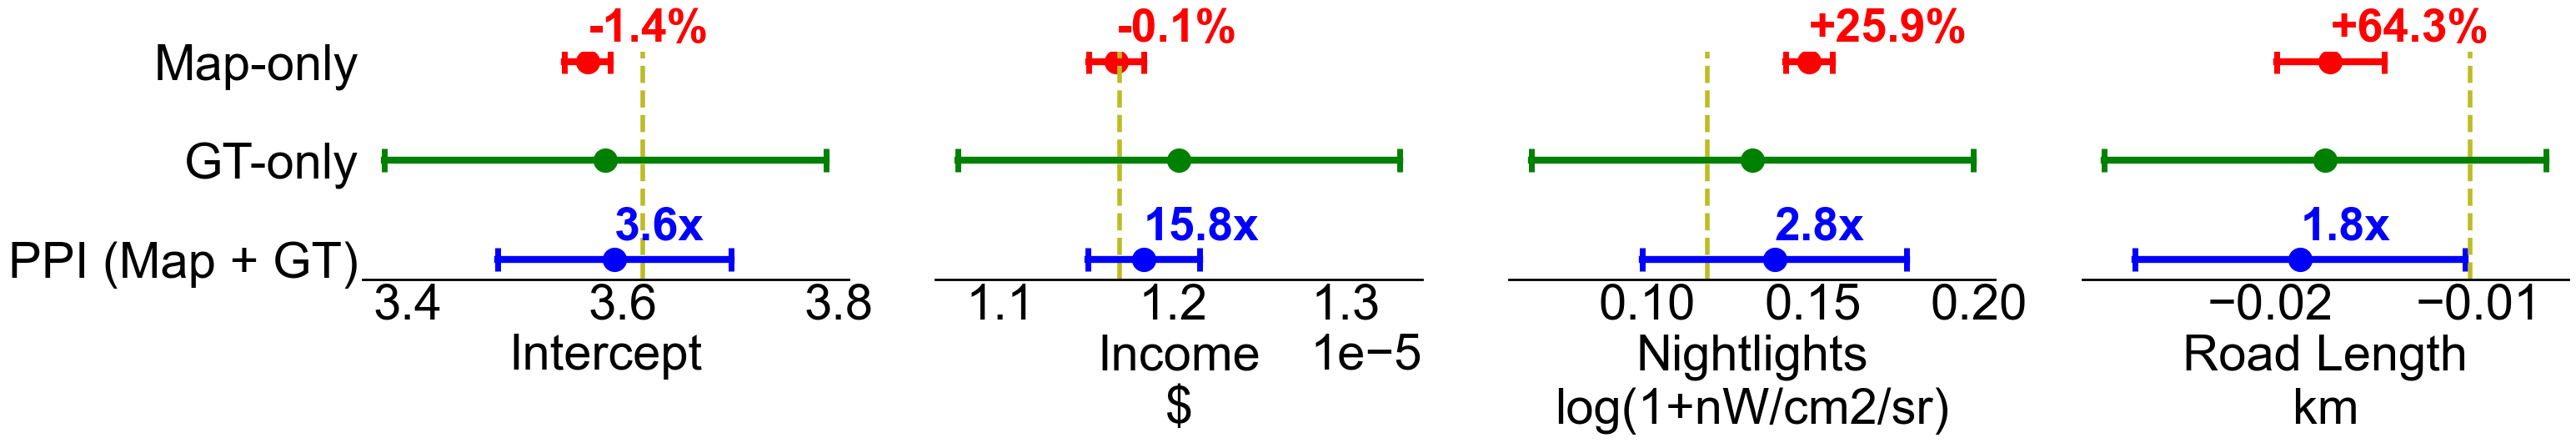

In [16]:
pd.set_option("display.precision", 8)

ppi_avg_estimates = np.array(ppi_estimates).mean(axis=0)
ppi_avg_widths = np.array(ppi_ci_widths).mean(axis=0)

classical_avg_estimates = np.array(classical_estimates).mean(axis=0)
classical_avg_widths = np.array(classical_ci_widths).mean(axis=0)

covariates_dict = {'Intercept': 'Intercept', 
                   'Income': 'Income\n$', 
                   'Nightlights': 'Nightlights\nlog(1+nW/cm2/sr)',
                  'Road Length': 'Road Length\nkm'}

# https://stackoverflow.com/questions/59747313/how-can-i-plot-a-confidence-interval-in-python
fig = plt.figure(figsize=(32, 6.5))
colors = ['blue', 'green', 'red']
for i, column in enumerate(covariates):
        
    data_dict = {}
    ppi_effective_n = int(np.round(Y.shape[0]*(classical_avg_widths[i]/ppi_avg_widths[i])**2))
    data_dict['category'] = ['PPI (Map + GT)',
                             'GT-only',
                             'Map-only']
    data_dict['lower'] = [ppi_avg_estimates[i] - ppi_avg_widths[i]/2, classical_avg_estimates[i] - classical_avg_widths[i]/2, map_only_estimates[i] - map_only_widths[i]/2]
    data_dict['upper'] = [ppi_avg_estimates[i] + ppi_avg_widths[i]/2, classical_avg_estimates[i] + classical_avg_widths[i]/2, map_only_estimates[i] + map_only_widths[i]/2]
    dataset = pd.DataFrame(data_dict)
    
    display(dataset)
    
    subplot = fig.add_subplot(141+i)
    #ax = subplot.gca()
    subplot.spines['top'].set_visible(False)
    subplot.spines['right'].set_visible(False)
    subplot.spines['left'].set_visible(False)
    subplot.spines['bottom'].set_linewidth(2)
    
    # show true coefficient
    plt.axvline(true_coeff[i], color='tab:olive', linestyle='--', lw=4, label='True \ncoefficient')
    '''
    if i == 3:
        plt.legend(prop={'size':40}, loc=(0.9, 0.9))
    '''

    for lower,upper,y in zip(dataset['lower'],dataset['upper'],range(len(dataset))):
        subplot.scatter([(lower+upper)/2], [y], color=colors[y], s=400)
        subplot.scatter([lower, upper], [y, y], color=colors[y], marker='|', s=400, lw=5)
        subplot.plot((lower,upper),(y,y),color=colors[y], lw=6)
        if y == 0:
            # compute PPI effective sample size improvement over GT-only
            ppi_effective_n = np.round(ppi_effective_n/len(X), 1)
            subplot.text((lower+upper)/2, 0.2, f'{ppi_effective_n}x', fontsize = 40, c='blue', weight='bold')
        if y == 2:
            # compute map-only estimate bias
            map_only_bias = np.round(100*(map_only_estimates[i] - true_coeff[i])/true_coeff[i], 1) 
            subplot.text((lower+upper)/2, 2.2, f'{map_only_bias:+g}%', fontsize = 40, c='red', weight='bold')
            
    subplot.tick_params(axis=u'both', which=u'both',length=0)
    if i == 0:
        subplot.set_yticks(range(len(dataset)),list(dataset['category']))
    else:
        subplot.set_yticks([])
    subplot.set_xlabel(f'{covariates_dict[column]}')
    subplot.set_ylim(-0.2)
    
plt.tight_layout()   
plt.savefig(f'output_images/housing_price_lin_reg_all.png', dpi=300, bbox_inches='tight')
plt.show()